In [27]:
#FACULDADE DE TECNOLOGIA DO ESTADO DE SÃO PAULO - COTIA

#Disciplina: Análise Preditiva
#Prof Iza Melão

#Equipe:

#Leonardo Freitas;
#Gabriel Silva;
#Marcelo Oliveira.

In [50]:
import pandas as pd
import numpy as np
import scipy 

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_digits
from sklearn.decomposition import FactorAnalysis

In [51]:
!pip install factor_analyzer==0.3.2
!pip install scipy==1.11.4



#Fonte: https://pypi.org/project/facot_analyzer
#Fonte: https://www.datacamp.com./community/tutorials/introduction.factor-analysis

from factor_analyzer import FactorAnalyzer

In [52]:
!pip show factor_analyzer

Name: factor_analyzer
Version: 0.3.2
Summary: A Factor Analysis class
Home-page: https://github.com/EducationalTestingService/factor_analyzer
Author: Jeremy Biggs
Author-email: jbiggs@ets.org
License: 
Location: C:\Users\Win10\anaconda3\Lib\site-packages
Requires: numpy, pandas, scikit-learn, scipy
Required-by: 


In [53]:
df = pd.read_csv("cereal.csv")
df.head()

,Cereals,Filling,Natural,Fibre,Sweet,Easy,Salt,Satisfying,Energy,Fun,...,Plain,Crisp,Regular,Sugar,Fruit,Process,Quality,Treat,Boring,Nutritious
0,Weetabix,5,5,5,1,2,1,5,4,1,...,3,1,4,1,1,3,5,1,1,5
1,SpecialK,1,2,2,1,5,2,5,1,1,...,5,5,1,2,1,5,2,1,1,3
2,SpecialK,5,4,5,5,5,3,5,5,5,...,1,5,4,3,1,2,5,4,1,5
3,CMuesli,5,5,5,3,5,2,5,5,5,...,1,1,4,2,5,2,5,5,1,5
4,CornFlakes,4,5,3,2,5,2,5,4,5,...,1,5,3,1,1,3,5,5,1,4


In [54]:
df = df.rename(columns = { 'Observacao_ID': 'Voluntário'})

In [55]:
df.head()

,Cereals,Filling,Natural,Fibre,Sweet,Easy,Salt,Satisfying,Energy,Fun,...,Plain,Crisp,Regular,Sugar,Fruit,Process,Quality,Treat,Boring,Nutritious
0,Weetabix,5,5,5,1,2,1,5,4,1,...,3,1,4,1,1,3,5,1,1,5
1,SpecialK,1,2,2,1,5,2,5,1,1,...,5,5,1,2,1,5,2,1,1,3
2,SpecialK,5,4,5,5,5,3,5,5,5,...,1,5,4,3,1,2,5,4,1,5
3,CMuesli,5,5,5,3,5,2,5,5,5,...,1,1,4,2,5,2,5,5,1,5
4,CornFlakes,4,5,3,2,5,2,5,4,5,...,1,5,3,1,1,3,5,5,1,4


In [59]:
df['Cereals'] = pd.Categorical (df['Cereals'])


In [61]:
pd.crosstab(index=df['Cereals'], columns ='count')

col_0,count
Cereals,
AllBran,15
CMuesli,13
CornFlakes,27
JustRight,16
Komplete,14
NutriGrain,24
PMuesli,18
RiceBubbles,21
SpecialK,23


In [63]:
X = df.iloc[:, 2:27]
X

,Natural,Fibre,Sweet,Easy,Salt,Satisfying,Energy,Fun,Kids,Soggy,...,Plain,Crisp,Regular,Sugar,Fruit,Process,Quality,Treat,Boring,Nutritious
0,5,5,1,2,1,5,4,1,4,5,...,3,1,4,1,1,3,5,1,1,5
1,2,2,1,5,2,5,1,1,5,3,...,5,5,1,2,1,5,2,1,1,3
2,4,5,5,5,3,5,5,5,5,3,...,1,5,4,3,1,2,5,4,1,5
3,5,5,3,5,2,5,5,5,5,3,...,1,1,4,2,5,2,5,5,1,5
4,5,3,2,5,2,5,4,5,5,1,...,1,5,3,1,1,3,5,5,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,4,4,1,4,2,3,3,2,4,3,...,4,3,4,1,1,3,4,2,2,4
231,4,4,3,4,3,4,4,4,4,1,...,1,4,4,3,4,2,4,4,1,4
232,4,4,1,4,1,4,4,3,4,2,...,3,3,4,1,1,2,3,3,2,4
233,3,3,3,4,2,3,3,2,3,2,...,3,2,3,2,1,3,3,2,2,3


In [64]:
# Create factor analysis object and perform factor analysis

fa=FactorAnalyzer(n_factors=25, rotation='varimax')
fa.fit(X)

# Check Eigenvalues
ev, v = fa.get_eigenvalues()
ev


array([5.99140968, 3.81199778, 2.49674494, 1.64453944, 1.07726628,
       0.9329784 , 0.835731  , 0.73191423, 0.70018125, 0.67070579,
       0.64106016, 0.54244882, 0.52499918, 0.48363248, 0.41454111,
       0.38669853, 0.36182149, 0.336638  , 0.29409425, 0.27415937,
       0.24466064, 0.23556771, 0.20194788, 0.16426158])

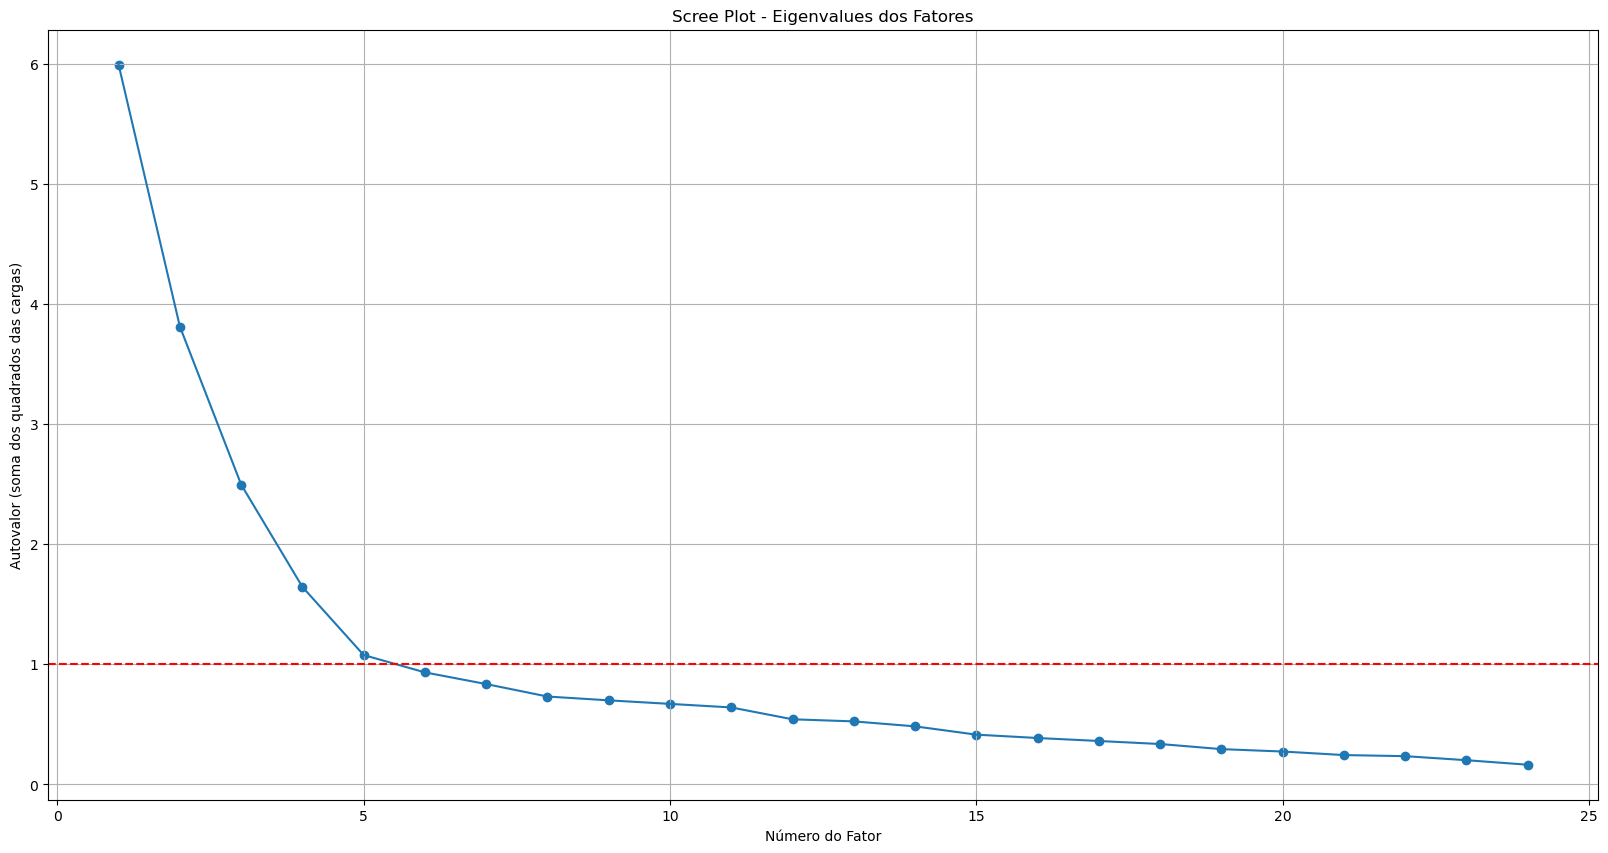

In [65]:
# Create scree plot using matplolib

plt.figure(figsize=(20,10))
plt.scatter(range(1, X.shape[1]+1), ev)
plt.plot(range(1, X.shape[1]+1), ev)
plt.title('Scree Plot - Eigenvalues dos Fatores')
plt.xlabel('Número do Fator')
plt.ylabel('Autovalor (soma dos quadrados das cargas)')
plt.axhline(y=1, color='red', linestyle='--')  # Linha de referência do critério de Kaiser

plt.grid()
plt.show()


In [66]:
# Vamos considerar 4 fatores

In [68]:
#Análise Fatorial com fatores não rotacionais

fa = FactorAnalyzer(n_factors=4, rotation=None)
fa.fit(X)

FactorAnalyzer(n_factors=4, rotation=None, rotation_kwargs={})

In [69]:
# Matriz L de cargas fatoriais estimada

L = fa.loadings_
np.round(L, 2)

array([[ 0.73, -0.22, -0.11,  0.12],
       [ 0.72, -0.22, -0.31,  0.19],
       [ 0.05,  0.74, -0.21,  0.15],
       [ 0.31,  0.15,  0.19,  0.12],
       [-0.24,  0.5 , -0.14,  0.42],
       [ 0.69,  0.2 ,  0.15,  0.16],
       [ 0.67,  0.15, -0.07,  0.11],
       [ 0.38,  0.51,  0.2 , -0.14],
       [ 0.21,  0.29,  0.76,  0.12],
       [-0.1 , -0.23,  0.15,  0.39],
       [ 0.16, -0.22,  0.47,  0.11],
       [ 0.82, -0.28, -0.12,  0.11],
       [ 0.3 ,  0.23,  0.67,  0.02],
       [-0.2 ,  0.55, -0.17,  0.2 ],
       [-0.3 , -0.37,  0.23,  0.43],
       [ 0.29,  0.46,  0.2 , -0.15],
       [ 0.58, -0.11, -0.19,  0.1 ],
       [-0.28,  0.73, -0.25,  0.27],
       [ 0.36,  0.26, -0.48, -0.13],
       [-0.3 ,  0.26,  0.01,  0.24],
       [ 0.74, -0.11,  0.04,  0.01],
       [ 0.46,  0.59,  0.06, -0.18],
       [-0.39, -0.28, -0.08,  0.32],
       [ 0.81, -0.19, -0.16,  0.18]])

In [70]:
fa.get_factor_variance()

(array([5.57508941, 3.35305457, 2.05064101, 1.08228784]),
 array([0.23229539, 0.13971061, 0.08544338, 0.04509533]),
 array([0.23229539, 0.372006  , 0.45744937, 0.5025447 ]))

In [71]:
# Análise fatorial com fatores rotacionados (varimax, testar outras)

fa = FactorAnalyzer(n_factors=4, rotation = 'varimax')
fa.fit(X)

FactorAnalyzer(n_factors=4, rotation='varimax', rotation_kwargs={})

In [72]:
# Matrix L de cargas fatoriais estimadas

L = pd.DataFrame(fa.loadings_)
np.round(L, 2)
L.index = X.columns
L.columns = ['Fa1', 'Fa2', 'Fa3', 'Fa4']
L

,Fa1,Fa2,Fa3,Fa4
Natural,0.750259,-0.198162,0.071829,0.043789
Fibre,0.825044,-0.099390,-0.100966,0.028752
Sweet,0.047413,0.696390,0.086267,0.351098
Easy,0.231742,0.067923,0.333129,0.057562
Salt,-0.098610,0.691030,0.016840,-0.086973
Satisfying,0.589719,0.068877,0.433074,0.177883
Energy,0.627451,0.071637,0.207324,0.221854
Fun,0.150688,0.178230,0.434029,0.468913
Kids,-0.045872,0.028134,0.850042,-0.007909
Soggy,0.037480,0.016633,0.084649,-0.480027


In [73]:
# Maiores cargas nos primeiros dois fatores

L.sort_values(by='Fa1', ascending=False).head(10)

,Fa1,Fa2,Fa3,Fa4
Nutritious,0.851029,-0.150801,0.073748,0.051111
Health,0.841020,-0.267016,0.072026,0.044439
Fibre,0.825044,-0.099390,-0.100966,0.028752
Natural,0.750259,-0.198162,0.071829,0.043789
Quality,0.658534,-0.225246,0.225794,0.162788
Energy,0.627451,0.071637,0.207324,0.221854
Regular,0.619924,-0.082990,-0.010358,0.088339
Satisfying,0.589719,0.068877,0.433074,0.177883
Fruit,0.380133,0.195736,-0.247194,0.453558
Treat,0.233018,0.238936,0.358304,0.591760


In [74]:
np.round(fa.get_communalities(),2)

array([0.61, 0.7 , 0.62, 0.17, 0.5 , 0.57, 0.49, 0.46, 0.73, 0.24, 0.31,
       0.79, 0.59, 0.41, 0.47, 0.36, 0.4 , 0.74, 0.45, 0.22, 0.56, 0.59,
       0.34, 0.76])

In [ ]:
# Sugestão de denominação do primeiro fator: SAUDÁVEL


In [75]:
L.sort_values(by='Fa2', ascending=False).head(10)

,Fa1,Fa2,Fa3,Fa4
Sugar,-0.190665,0.822775,-0.047049,0.162168
Sweet,0.047413,0.696390,0.086267,0.351098
Salt,-0.098610,0.691030,0.016840,-0.086973
Calories,-0.137780,0.613171,-0.006691,0.128319
Process,-0.226377,0.381696,0.023879,-0.135078
Treat,0.233018,0.238936,0.358304,0.591760
Fruit,0.380133,0.195736,-0.247194,0.453558
Fun,0.150688,0.178230,0.434029,0.468913
Crisp,0.075151,0.155638,0.389520,0.419793
Energy,0.627451,0.071637,0.207324,0.221854


In [ ]:
# Sugestão de denominação do segundo fator: Artificial ou Não saudável

In [76]:
L.sort_values(by='Fa3', ascending=False).head(10)

,Fa1,Fa2,Fa3,Fa4
Kids,-0.045872,0.028134,0.850042,-0.007909
Family,0.039973,-0.061842,0.761821,0.075594
Fun,0.150688,0.178230,0.434029,0.468913
Satisfying,0.589719,0.068877,0.433074,0.177883
Economical,0.071270,-0.276318,0.411229,-0.242618
Crisp,0.075151,0.155638,0.389520,0.419793
Treat,0.233018,0.238936,0.358304,0.591760
Easy,0.231742,0.067923,0.333129,0.057562
Quality,0.658534,-0.225246,0.225794,0.162788
Energy,0.627451,0.071637,0.207324,0.221854


In [ ]:
# Sugestão de denominação do terceiro fator: Familiar

In [77]:
L.sort_values(by='Fa4', ascending=False).head(10)

,Fa1,Fa2,Fa3,Fa4
Treat,0.233018,0.238936,0.358304,0.591760
Fun,0.150688,0.178230,0.434029,0.468913
Fruit,0.380133,0.195736,-0.247194,0.453558
Crisp,0.075151,0.155638,0.389520,0.419793
Sweet,0.047413,0.696390,0.086267,0.351098
Energy,0.627451,0.071637,0.207324,0.221854
Satisfying,0.589719,0.068877,0.433074,0.177883
Quality,0.658534,-0.225246,0.225794,0.162788
Sugar,-0.190665,0.822775,-0.047049,0.162168
Calories,-0.137780,0.613171,-0.006691,0.128319


In [ ]:
# Sugestão de denominação do quarto fator: Indulgência e Satisfação

In [78]:
# Variância explicada por cada fator:

fa.get_factor_variance()

(array([4.68877112, 2.61566349, 2.49950723, 2.25713098]),
 array([0.19536546, 0.10898598, 0.10414613, 0.09404712]),
 array([0.19536546, 0.30435144, 0.40849758, 0.5025447 ]))

In [79]:
np.sum(fa.get_factor_variance())

13.97437670337637

In [80]:
fa.get_factor_variance()/np.sum(fa.get_factor_variance())

array([[0.33552632, 0.18717568, 0.17886359, 0.16151926],
       [0.01398026, 0.00779899, 0.00745265, 0.00672997],
       [0.01398026, 0.02177925, 0.0292319 , 0.03596187]])

In [81]:
# Variância percentual explicada por cada fator:

np.round(fa.get_factor_variance()/np.sum(fa.get_factor_variance()),2)

array([[0.34, 0.19, 0.18, 0.16],
       [0.01, 0.01, 0.01, 0.01],
       [0.01, 0.02, 0.03, 0.04]])

In [88]:
df[['Fa1', 'Fa2','Fa3','Fa4']] = np.array(fa.fit_transform(X))[:, 0:4]

In [89]:
df.sort_values(by='Fa1', ascending=False).head(10)

,Cereals,Filling,Natural,Fibre,Sweet,Easy,Salt,Satisfying,Energy,Fun,...,Boring,Nutritious,Fa1,Fa2,Fa3,Fa4,Fator 1,Fator 2,Fator 3,Fator 4
40,Sustain,5,5,5,5,5,3,5,5,5,...,1,5,1.827711,1.867018,0.691142,0.915932,1.827711,1.867018,0.691142,0.915932
73,Komplete,4,5,5,3,3,2,3,5,2,...,3,5,1.778219,0.725700,-2.041730,-0.139463,1.778219,0.725700,-2.041730,-0.139463
158,Vitabrit,5,5,5,4,5,4,5,5,2,...,1,5,1.747081,0.968091,-0.016436,-1.675357,1.747081,0.968091,-0.016436,-1.675357
31,AllBran,5,4,5,1,5,2,5,5,2,...,4,5,1.673741,-0.134329,-1.157931,-0.745910,1.673741,-0.134329,-1.157931,-0.745910
206,JustRight,3,5,5,4,5,3,4,5,5,...,2,5,1.655577,1.342514,0.705336,0.274670,1.655577,1.342514,0.705336,0.274670
3,CMuesli,5,5,5,3,5,2,5,5,5,...,1,5,1.640304,-0.012712,0.571300,1.038095,1.640304,-0.012712,0.571300,1.038095
78,Vitabrit,5,5,5,2,4,1,5,5,2,...,3,5,1.631055,-0.276671,0.954199,-1.139320,1.631055,-0.276671,0.954199,-1.139320
153,Weetabix,5,5,5,2,5,2,5,5,2,...,1,5,1.623304,-0.123433,1.234925,-1.281149,1.623304,-0.123433,1.234925,-1.281149
208,PMuesli,4,5,5,3,5,1,5,4,3,...,1,5,1.618179,-0.623278,-0.935918,1.198523,1.618179,-0.623278,-0.935918,1.198523
205,Weetabix,4,5,5,2,5,2,5,4,3,...,3,5,1.601388,0.020870,0.551942,-1.324081,1.601388,0.020870,0.551942,-1.324081


In [90]:
df[df['Cereals']==15]

,Cereals,Filling,Natural,Fibre,Sweet,Easy,Salt,Satisfying,Energy,Fun,...,Boring,Nutritious,Fa1,Fa2,Fa3,Fa4,Fator 1,Fator 2,Fator 3,Fator 4
